# Train Baseline Models

### Purpose

**This notebook develops and evaluates baseline predictive models for the multimodal survival dataset.**

### Objectives
- Train interpretable baseline models using clinical and RNA features
- Establish a performance floor for the prediction task
- Evaluate predictive discrimination and calibration
- Quantify the incremental predictive value of RNA relative to clinical data
- Prototype modeling and evaluation steps before implementation in the pipeline

### Workflow

1. Load and inspect assembled datasets
   - Load preprocessed feature matrices and outcome labels produced by the data assembly step.
   - Confirm expected shapes and feature counts for clinical and RNA datasets.
   - Verify sample alignment between features and outcome labels.

**Subsequent exploratory steps use the training and validation data only.**

2. Train clinical-only logistic regression  
   - Fit a logistic regression model using clinical features only.  
   - Use L2 regularization.  
   - Select regularization strength `C` via `LogisticRegressionCV` on the training set (stratified k-fold).

3. Train RNA-only logistic regression  
   - Fit a logistic regression model using RNA expression features only.  
   - Use L2 regularization appropriate for high-dimensional data.  
   - Select regularization strength `C` via `LogisticRegressionCV` on the training set (stratified k-fold).

4. Generate validation predictions  
   - Produce predicted probabilities for the validation set.  
   - Evaluate discrimination metrics.

5. Evaluate model performance  
   - Compute ROC-AUC and average precision (AP) as primary discrimination metrics.  
   - Generate calibration curve as diagnostic check.  
   - Compare performance between clinical and RNA models.

6. Evaluate risk-tier separation  
   - Bin patients into three tiers by predicted probability: top 20% (high-risk), middle 60%, bottom 20% (low-risk).  
   - Examine outcome rates across tiers.  
   - Report event rate in the top-20% tier as the primary risk-capture metric (consistent with ablation in later steps).

**Now evaluate on test data.**

7. Evaluate final models on the test set  
   - Generate test predictions using the selected models.  
   - Compute final evaluation metrics.  
   - Validation set is reserved for unbiased model comparison; `C` was selected via cross-validation on the training set only.

8. Validate modeling outputs  
   - Confirm prediction counts match split sizes  
   - Verify sample alignment across datasets  
   - Verify no data leakage between splits

9. Test train baselines module

## 1. Load and inspect assembled datasets
   - Load preprocessed feature matrices and outcome labels produced by the data assembly step.
   - Confirm expected shapes and feature counts for clinical and RNA datasets.
   - Verify sample alignment between features and outcome labels.

In [79]:
from pathlib import Path
import sys
import subprocess
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

from IPython.display import display

In [80]:
# Load and inspect assembled datasets

def load_assembled_datasets(
    assembled_dir: Path,
) -> tuple[
    pd.DataFrame, pd.DataFrame, pd.DataFrame,
    pd.DataFrame, pd.DataFrame, pd.DataFrame,
    pd.Series, pd.Series, pd.Series,
]:
    """Load assembled train/val/test feature matrices and targets from parquet files.

    Parameters:
    - assembled_dir: path to the assembled dataset directory

    Returns:
    - X_clin_train_df, X_clin_val_df, X_clin_test_df: clinical feature matrices
    - X_rna_train_df, X_rna_val_df, X_rna_test_df: RNA feature matrices
    - y_train, y_val, y_test: binary outcome vectors
    """
    assembled_dir = Path(assembled_dir)

    X_clin_train_df = pd.read_parquet(assembled_dir / "train/X_clinical.parquet")
    X_clin_val_df   = pd.read_parquet(assembled_dir / "val/X_clinical.parquet")
    X_clin_test_df  = pd.read_parquet(assembled_dir / "test/X_clinical.parquet")

    X_rna_train_df  = pd.read_parquet(assembled_dir / "train/X_rna.parquet")
    X_rna_val_df    = pd.read_parquet(assembled_dir / "val/X_rna.parquet")
    X_rna_test_df   = pd.read_parquet(assembled_dir / "test/X_rna.parquet")

    y_train = pd.read_parquet(assembled_dir / "train/y.parquet")["y"]
    y_val   = pd.read_parquet(assembled_dir / "val/y.parquet")["y"]
    y_test  = pd.read_parquet(assembled_dir / "test/y.parquet")["y"]

    for split, X_clin, X_rna, y in [
        ("train", X_clin_train_df, X_rna_train_df, y_train),
        ("val",   X_clin_val_df,   X_rna_val_df,   y_val),
        ("test",  X_clin_test_df,  X_rna_test_df,  y_test),
    ]:
        assert X_clin.index.equals(X_rna.index), f"{split}: clinical/RNA index mismatch"
        assert X_clin.index.equals(y.index),     f"{split}: clinical/y index mismatch"
        print(f"{split}: n={len(y)}, n_events={y.sum()}, clin={X_clin.shape[1]} features, rna={X_rna.shape[1]} features")

    return (
        X_clin_train_df, X_clin_val_df, X_clin_test_df,
        X_rna_train_df, X_rna_val_df, X_rna_test_df,
        y_train, y_val, y_test,
    )


assembled_dir = Path("../data/processed/assembled")
(
    X_clin_train_df, X_clin_val_df, X_clin_test_df,
    X_rna_train_df, X_rna_val_df, X_rna_test_df,
    y_train, y_val, y_test,
) = load_assembled_datasets(assembled_dir)

# Spot checks
assert y_train.index.equals(X_clin_train_df.index)
assert y_val.index.equals(X_clin_val_df.index)
assert y_test.index.equals(X_clin_test_df.index)

train: n=203, n_events=66, clin=98 features, rna=25431 features
val: n=43, n_events=14, clin=98 features, rna=25431 features
test: n=44, n_events=14, clin=98 features, rna=25431 features


## 2. Train clinical-only logistic regression  
   - Fit a logistic regression model using clinical features only.  
   - Use L2 regularization.  
   - Select regularization strength `C` via `LogisticRegressionCV` on the training set (stratified k-fold).

In [81]:
# Fit scaler on train only; apply to val and test

def fit_and_apply_scaler(
    X_train_df: pd.DataFrame,
    X_val_df: pd.DataFrame,
    X_test_df: pd.DataFrame,
) -> tuple[StandardScaler, np.ndarray, np.ndarray, np.ndarray]:
    """Fit a StandardScaler on training data and apply to all splits.

    Parameters:
    - X_train_df, X_val_df, X_test_df: feature matrices for each split

    Returns:
    - scaler: fitted StandardScaler
    - X_train_scaled, X_val_scaled, X_test_scaled: scaled arrays
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df)
    X_val_scaled = scaler.transform(X_val_df)
    X_test_scaled = scaler.transform(X_test_df)
    return scaler, X_train_scaled, X_val_scaled, X_test_scaled


scaler_clin, X_clin_train_scaled, X_clin_val_scaled, X_clin_test_scaled = fit_and_apply_scaler(
    X_clin_train_df, X_clin_val_df, X_clin_test_df
)

# RNA is pre-scaled in preprocessing — use values directly
X_rna_train_scaled = X_rna_train_df.values
X_rna_val_scaled   = X_rna_val_df.values
X_rna_test_scaled  = X_rna_test_df.values

# Check shapes and that clinical train mean is ~0 after scaling
assert X_clin_train_scaled.shape == X_clin_train_df.shape
assert abs(X_clin_train_scaled.mean()) < 0.01

In [82]:
# Select C via stratified 5-fold CV on training data only; val set stays untouched

def fit_logistic_regression(
    X_train_scaled: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> tuple[LogisticRegressionCV, float, float]:
    """Fit logistic regression with L2 regularization, selecting C via stratified 5-fold CV.

    Parameters:
    - X_train_scaled: scaled training feature matrix
    - y_train: binary outcome vector
    - random_state: random seed for reproducibility

    Returns:
    - model: fitted LogisticRegressionCV
    - best_c: selected regularization strength
    - best_cv_auc: mean ROC-AUC at best C across CV folds
    """
    model = LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l2",
        scoring="roc_auc",
        solver="lbfgs",
        max_iter=1000,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X_train_scaled, y_train)

    best_c_idx = model.Cs_.tolist().index(model.C_[0])
    best_cv_auc = model.scores_[1].mean(axis=0)[best_c_idx]

    print(f"Best C: {model.C_[0]:.4f}")
    print(f"Train AUC (CV mean at best C): {best_cv_auc:.3f}")

    return model, model.C_[0], best_cv_auc


lr_clin, best_c_clin, best_cv_auc_clin = fit_logistic_regression(X_clin_train_scaled, y_train)

# Check model fitted and predictions are valid probabilities
assert lr_clin.C_[0] == best_c_clin
assert 0.5 < best_cv_auc_clin <= 1.0

Best C: 0.0060
Train AUC (CV mean at best C): 0.855


## 3. Train RNA-only logistic regression  
   - Fit a logistic regression model using RNA expression features only.  
   - Use L2 regularization appropriate for high-dimensional data.  
   - Select regularization strength `C` via `LogisticRegressionCV` on the training set (stratified k-fold).

In [83]:
# Fit RNA-only logistic regression with L2 regularization
# High-dimensional features (~5000 genes) — stronger regularization expected

lr_rna, best_c_rna, best_cv_auc_rna = fit_logistic_regression(X_rna_train_scaled, y_train)

# Check model fitted and predictions are valid probabilities
assert lr_rna.C_[0] == best_c_rna
assert 0.5 < best_cv_auc_rna <= 1.0

Best C: 2.7826
Train AUC (CV mean at best C): 0.684


## 4. Generate validation predictions  
   - Produce predicted probabilities for the validation set.  
   - Evaluate discrimination metrics.

In [84]:
# Generate validation predictions for both models

def evaluate_predictions(
    lr_clin: LogisticRegressionCV,
    lr_rna: LogisticRegressionCV,
    X_clin_scaled: np.ndarray,
    X_rna_scaled: np.ndarray,
    y_true: pd.Series,
    split: str,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Generate predictions and compute discrimination metrics for both models.

    Parameters:
    - lr_clin, lr_rna: fitted clinical and RNA logistic regression models
    - X_clin_scaled, X_rna_scaled: scaled feature matrices
    - y_true: binary outcome vector
    - split: split name used for column prefixes (e.g. "val", "test")

    Returns:
    - y_pred_clin, y_pred_rna: predicted probabilities
    - metrics_df: ROC-AUC and AP for each model
    """
    y_pred_clin = lr_clin.predict_proba(X_clin_scaled)[:, 1]
    y_pred_rna = lr_rna.predict_proba(X_rna_scaled)[:, 1]

    metrics_df = pd.DataFrame({
        "model": ["clinical", "rna"],
        f"{split}_roc_auc": [
            roc_auc_score(y_true, y_pred_clin),
            roc_auc_score(y_true, y_pred_rna),
        ],
        f"{split}_ap": [
            average_precision_score(y_true, y_pred_clin),
            average_precision_score(y_true, y_pred_rna),
        ],
    })

    display(metrics_df)
    return y_pred_clin, y_pred_rna, metrics_df


y_val_pred_clin, y_val_pred_rna, val_metrics_df = evaluate_predictions(
    lr_clin, lr_rna, X_clin_val_scaled, X_rna_val_scaled, y_val, split="val"
)

assert len(y_val_pred_clin) == len(y_val)
assert len(y_val_pred_rna) == len(y_val)
assert (val_metrics_df["val_roc_auc"].between(0, 1)).all()
assert (val_metrics_df["val_ap"].between(0, 1)).all()


,model,val_roc_auc,val_ap
0,clinical,0.884236,0.826249
1,rna,0.709360,0.575223


In [85]:
# Sanity check top clinical features by absolute coefficient magnitude

coef_df = pd.DataFrame({
    "feature": X_clin_train_df.columns,
    "coefficient": lr_clin.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)
display(coef_df.head(20))

,feature,coefficient
48,ajcc_staging_system_edition.diagnoses_7th,0.133380
47,ajcc_staging_system_edition.diagnoses_6th,-0.124767
2,age_at_earliest_diagnosis_in_years.diagnoses.x...,0.100550
0,year_of_birth.demographic,-0.094459
33,ajcc_pathologic_stage.diagnoses_Stage IV,0.092045
7,ajcc_pathologic_m.diagnoses_M1,0.092045
12,ajcc_pathologic_n.diagnoses_N0 (i-),-0.089467
56,name.tissue_source_site_Asterand,0.079672
15,ajcc_pathologic_n.diagnoses_N1b,0.072143
29,ajcc_pathologic_stage.diagnoses_Stage III,0.065167


### Clinical Model Coefficient Inspection

Top coefficients are broadly interpretable:

- **Stage IV / M1 / N1b / T4b / Stage III**
    - positive coefficients; advanced disease predicts worse survival as expected.
- **N0(i-)**
    - negative coefficient; node-negative predicts better survival, consistent with biology.
- **Age at diagnosis**
    - positive; older patients have worse prognosis.
- **Secretory carcinoma**
    - positive coefficient is surprising given this subtype typically has better prognosis; likely a small-n artifact.
- **Staging edition / year of birth**
    - prominent but reflect temporal cohort effects rather than biology (earlier editions = older diagnoses = different treatment era).
- **Collection site effects (Asterand, Pittsburgh, Indivumed)**
    - administrative noise; the model is partially fitting site-level confounders rather than patient biology.

Overall: the model captures real prognostic signal but mixes it with site and temporal confounders. This is expected for a simple L2-regularized logistic regression on heterogeneous clinical data and motivates more careful feature selection in later steps.


## 5. Evaluate model performance  
   - Compute ROC-AUC and average precision (AP) as primary discrimination metrics.  
   - Generate calibration curve and Brier score as diagnostic checks.  
   - No recalibration is applied: raw LR probabilities are used throughout. Calibration is treated as a sanity check rather than a modeling decision — the primary evaluation is rank-based (AUC, AP, top-20% capture).  
   - Compare performance between clinical and RNA models.

In [86]:
# Validation discrimination metrics

val_metrics_df = pd.DataFrame({
    "model": ["clinical", "rna"],
    "val_roc_auc": [
        roc_auc_score(y_val, y_val_pred_clin),
        roc_auc_score(y_val, y_val_pred_rna),
    ],
    "val_ap": [
        average_precision_score(y_val, y_val_pred_clin),
        average_precision_score(y_val, y_val_pred_rna),
    ],
})
display(val_metrics_df)

,model,val_roc_auc,val_ap
0,clinical,0.884236,0.826249
1,rna,0.709360,0.575223


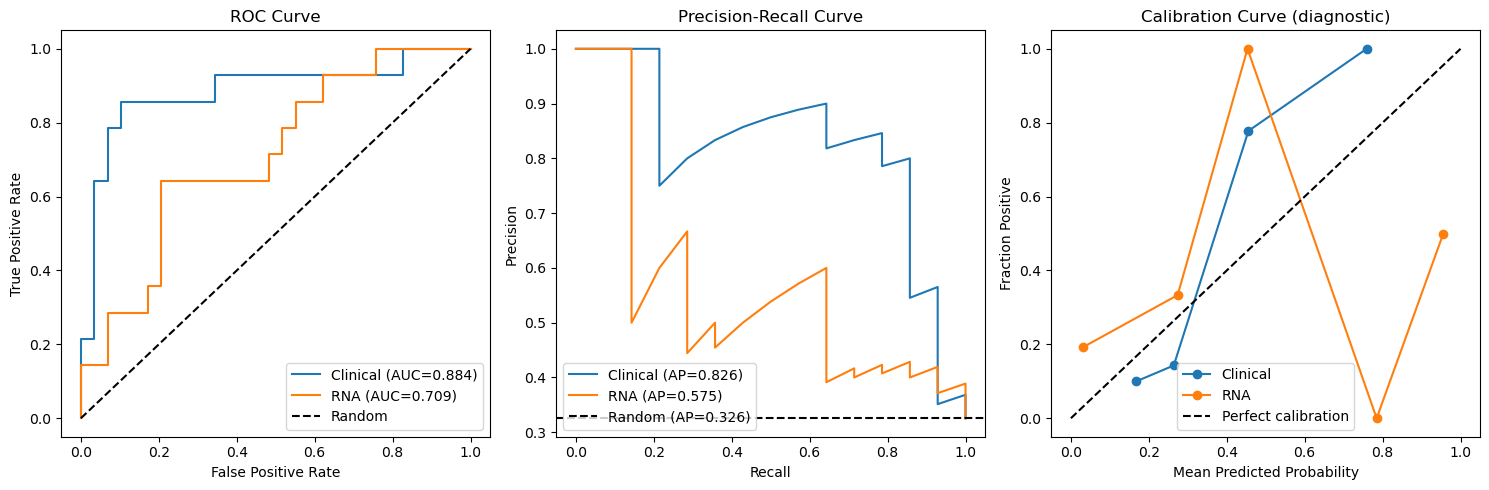

In [87]:
# Model performance visualizations

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC
ax = axes[0]
for name, preds in [("Clinical", y_val_pred_clin), ("RNA", y_val_pred_rna)]:
    fpr, tpr, _ = roc_curve(y_val, preds)
    auc = roc_auc_score(y_val, preds)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

# Precision-Recall
ax = axes[1]
for name, preds in [("Clinical", y_val_pred_clin), ("RNA", y_val_pred_rna)]:
    prec, rec, _ = precision_recall_curve(y_val, preds)
    ap = average_precision_score(y_val, preds)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
baseline = y_val.mean()
ax.axhline(baseline, color="k", linestyle="--", label=f"Random (AP={baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

# Calibration curves — diagnostic only, no recalibration applied
ax = axes[2]
for name, preds in [("Clinical", y_val_pred_clin), ("RNA", y_val_pred_rna)]:
    fraction_pos, mean_pred = calibration_curve(y_val, preds, n_bins=5)
    ax.plot(mean_pred, fraction_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction Positive")
ax.set_title("Calibration Curve (diagnostic)")
ax.legend()

plt.tight_layout()
plt.show()

### Model performance results
- ROC: Clinical (AUC=0.884) substantially outperforms RNA (0.707); both well above random (0.5). Clinical staging likely drives the gap.
- PR: Clinical (AP=0.826) vs RNA (AP=0.574) vs random baseline (0.326); clinical precision remains high across recall levels, RNA degrades quickly.
- Calibration: Curves are uninterpretable at n~43 — bin noise dominates.

## 6. Evaluate risk-tier separation  
   - Bin patients into three tiers by predicted probability: top 20% (high-risk), middle 60%, bottom 20% (low-risk).  
   - Examine outcome rates across tiers.  
   - Report event rate in the top-20% tier as the primary risk-capture metric (consistent with ablation in later steps).

In [88]:
# Bin patients into risk tiers by predicted probability: top 20%, middle 60%, bottom 20%

def risk_tier_summary(y_true, y_pred, model_name):
    thresholds = np.percentile(y_pred, [80, 20])
    tiers = np.where(y_pred >= thresholds[0], "high",
             np.where(y_pred <= thresholds[1], "low", "mid"))
    
    df = pd.DataFrame({"y": y_true.values, "tier": tiers})
    summary = (
        df.groupby("tier")["y"]
        .agg(n="count", events="sum", event_rate="mean")
        .reindex(["high", "mid", "low"])
        .assign(model=model_name)
    )
    return summary

clin_tiers = risk_tier_summary(y_val, y_val_pred_clin, "clinical")
rna_tiers = risk_tier_summary(y_val, y_val_pred_rna, "rna")

display(clin_tiers)
display(rna_tiers)

,n,events,event_rate,model
tier,,,,
high,9,8,0.888889,clinical
mid,25,5,0.200000,clinical
low,9,1,0.111111,clinical


,n,events,event_rate,model
tier,,,,
high,9,4,0.444444,rna
mid,25,9,0.360000,rna
low,9,1,0.111111,rna


## Subsequent steps contain development code that is prototyped and validated in the notebook before being refactored into the module.

## 7. Evaluate final models on the test set  
   - Generate test predictions using the selected models.  
   - Compute final evaluation metrics.  
   - Validation set is reserved for unbiased model comparison; `C` was selected via cross-validation on the training set only.

In [89]:
# Final evaluation on the held-out test set — run once, after all model decisions are made

y_test_pred_clin = lr_clin.predict_proba(X_clin_test_scaled)[:, 1]
y_test_pred_rna = lr_rna.predict_proba(X_rna_test_scaled)[:, 1]

test_metrics_df = pd.DataFrame({
    "model": ["clinical", "rna"],
    "test_roc_auc": [
        roc_auc_score(y_test, y_test_pred_clin),
        roc_auc_score(y_test, y_test_pred_rna),
    ],
    "test_ap": [
        average_precision_score(y_test, y_test_pred_clin),
        average_precision_score(y_test, y_test_pred_rna),
    ],
})
display(test_metrics_df)

# Risk-tier separation on test set
clin_tiers_test = risk_tier_summary(y_test, y_test_pred_clin, "clinical")
rna_tiers_test = risk_tier_summary(y_test, y_test_pred_rna, "rna")
display(clin_tiers_test)
display(rna_tiers_test)

,model,test_roc_auc,test_ap
0,clinical,0.785714,0.675042
1,rna,0.623810,0.479174


,n,events,event_rate,model
tier,,,,
high,9,6,0.666667,clinical
mid,26,7,0.269231,clinical
low,9,1,0.111111,clinical


,n,events,event_rate,model
tier,,,,
high,9,5,0.555556,rna
mid,26,7,0.269231,rna
low,9,2,0.222222,rna



## 8. Validate modeling outputs  
   - Confirm prediction counts match split sizes  
   - Verify sample alignment across datasets  
   - Verify no data leakage between splits


In [90]:
# Confirm prediction counts match split sizes
assert len(y_val_pred_clin) == len(y_val), f"Clinical val pred count mismatch: {len(y_val_pred_clin)} != {len(y_val)}"
assert len(y_val_pred_rna) == len(y_val), f"RNA val pred count mismatch: {len(y_val_pred_rna)} != {len(y_val)}"
assert len(y_test_pred_clin) == len(y_test), f"Clinical test pred count mismatch: {len(y_test_pred_clin)} != {len(y_test)}"
assert len(y_test_pred_rna) == len(y_test), f"RNA test pred count mismatch: {len(y_test_pred_rna)} != {len(y_test)}"

# Verify no sample ID overlap between splits
train_ids = set(X_clin_train_df.index)
val_ids = set(X_clin_val_df.index)
test_ids = set(X_clin_test_df.index)
assert train_ids.isdisjoint(val_ids), "Leakage: train and val share sample IDs"
assert train_ids.isdisjoint(test_ids), "Leakage: train and test share sample IDs"
assert val_ids.isdisjoint(test_ids), "Leakage: val and test share sample IDs"

print("All validation checks passed.")
print(f"val predictions:  clin={len(y_val_pred_clin)}, rna={len(y_val_pred_rna)}")
print(f"test predictions: clin={len(y_test_pred_clin)}, rna={len(y_test_pred_rna)}")

All validation checks passed.
val predictions:  clin=43, rna=43
test predictions: clin=44, rna=44



## 9. Test train baselines module

In [91]:
# Test train baselines module - run the script and check it produces expected outputs without errors

# Run train_baselines module via CLI
result = subprocess.run(
    [
        sys.executable,
        "../scripts/train_baselines.py",
        "--assembled-dir", "../data/processed/assembled",
        "--outdir", "../models/baselines",
        "--random-state", "42",
    ],
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"train_baselines.py failed with exit code {result.returncode}")

# Load and validate artifacts match notebook-derived results
outdir = Path("../models/baselines")

with open(outdir / "clinical_model.pkl", "rb") as f:
    lr_clin_loaded = pickle.load(f)
with open(outdir / "rna_model.pkl", "rb") as f:
    lr_rna_loaded = pickle.load(f)

preds_val_df = pd.read_parquet(outdir / "predictions_val.parquet")
preds_test_df = pd.read_parquet(outdir / "predictions_test.parquet")
metrics = json.loads((outdir / "train_baselines_metadata.json").read_text())

assert lr_clin_loaded.C_[0] == lr_clin.C_[0], "Clinical model C mismatch"
assert lr_rna_loaded.C_[0] == lr_rna.C_[0], "RNA model C mismatch"
assert len(preds_val_df) == len(y_val)
assert len(preds_test_df) == len(y_test)
assert np.allclose(preds_val_df["y_pred_clin"].values, y_val_pred_clin)
assert np.allclose(preds_val_df["y_pred_rna"].values, y_val_pred_rna)

print("train_baselines module test passed.")
display(preds_val_df.head(), preds_val_df.tail())


train: n=203, n_events=66, clin=98 features, rna=25431 features
val: n=43, n_events=14, clin=98 features, rna=25431 features
test: n=44, n_events=14, clin=98 features, rna=25431 features

--- Clinical model ---
Best C: 0.0060
Train AUC (CV mean at best C): 0.855

--- RNA model ---
Best C: 2.7826
Train AUC (CV mean at best C): 0.684

--- Validation ---
   model  val_roc_auc   val_ap
clinical     0.884236 0.826249
     rna     0.709360 0.575223

--- Test ---
   model  test_roc_auc  test_ap
clinical      0.785714 0.675042
     rna      0.623810 0.479174

Artifacts saved to ../models/baselines

train_baselines module test passed.


,sample,y_true,y_pred_clin,y_pred_rna
0,TCGA-BH-A0DD-01A,0,0.269084,0.006388
1,TCGA-A2-A0D3-01A,0,0.146023,0.004044
2,TCGA-OL-A5D6-01A,1,0.360627,0.032706
3,TCGA-A2-A0CO-01A,1,0.492941,0.000473
4,TCGA-A8-A09X-01A,1,0.405213,0.041853


,sample,y_true,y_pred_clin,y_pred_rna
38,TCGA-AO-A1KR-01A,0,0.197696,0.001151
39,TCGA-AO-A1KP-01A,0,0.257120,0.979578
40,TCGA-B6-A0WZ-01A,0,0.351311,0.000575
41,TCGA-AO-A12B-01A,0,0.147269,0.990962
42,TCGA-AR-A1AH-01A,0,0.204333,0.876462
